In [1]:
import sys, os
sys.path.append("/cluster/home/vogtva/pde-data-gen")
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

In [2]:
import numpy as np
import pandas as pd
import json
import netCDF4 as nc
import src.db_tools as db_tools
import matplotlib.pyplot as plt
import seaborn as sns
from src.db_tools import (
    Dataset,
    get_dataset,
    expand_json_column,
    filter_df,
    filter_dataset
)
from src.plotting import (
    make_animation,
    plot,
    metrics_grid
)
import plotly.express as px
import plotly.graph_objects as go
import xarray as xr

In [3]:
model = "bruss"
ds_id = "grid2"
ds, output_dir = get_dataset(model, ds_id, "SCRATCHDIR")
df = ds.df
df["ratio_b_a"] = df["B"] / df["A"]
df["ratio_d"] = df["Dv"] / df["Du"]

In [26]:
remap_dict = {1: 0, 2: 1, 0:2}

df.pca_label = df.pca_label.map(remap_dict)

In [27]:
grouped_mean_dev = df.groupby(['A', 'ratio_b_a'])['mean_deviation'].mean().reset_index(name='avg_mean_deviation')
mean_pca = df.groupby(['A', 'ratio_b_a'])['pca_label'].mean().reset_index(name='mean_pca_label')
df_grp = grouped_mean_dev.merge(mean_pca, on=['A', 'ratio_b_a'], how='left')

In [30]:
remap_dict = {0: 0, 2: 2}

# Apply the mapping, using .map() and .fillna() for "all other" values
df_grp['mean_pca_label'] = df_grp['mean_pca_label'].map(remap_dict).fillna(1).astype(int)
df_grp['mean_pca_label'] = df_grp['mean_pca_label'].astype(str)

In [26]:
set1_colors = ['#E41A1C', '#377EB8', '#4DAF4A']
fig = px.scatter_3d(
    df_grp,
    x="A",
    y="ratio_b_a",
    z="avg_mean_deviation", 
    color="mean_pca_label", 
    color_discrete_sequence=set1_colors,
    labels={
        "ratio_b_a": "B/A",
        "avg_mean_deviation": "Averaged MeanDev",
    },
)
# fig.update_layout(
#     legend=dict(
#         font=dict(size=20),  # Increase legend font size[1][3][8]
#         title_font=dict(size=22),  # Increase legend title font size
#         bordercolor="black",
#         borderwidth=2
#     )
# )
fig.update_layout(
    scene_camera=dict(
        eye=dict(x=-1.5, y=-1.25, z=0.1),
        center=dict(x=0, y=0, z=-0.15)
    )
)

fig.update_traces(marker_size=1.5, marker=dict(line=dict(width=2, color='black')))
fig.write_image("grid_scatter_avg-mean-dev.png", width=1.5*500, height=1.5*300, scale=3)


ValueError: Value of 'z' is not the name of a column in 'data_frame'. Expected one of ['A', 'ratio_b_a', 'var_mean_deviation', 'mean_pca_label', 'merge_label'] but received: avg_mean_deviation

In [39]:
fig = go.Figure()
labels = ['Homogeneous', 'Transitory and large-scale patterns', 'Short-scale patterns']
colors = ['#E41A1C', '#377EB8', '#4DAF4A']

for label, color in zip(labels, colors):
    fig.add_trace(go.Scatter(
        x=[None], y=[None],  # No data shown
        mode='markers',
        marker=dict(size=15, color=color, line=dict(width=2, color='black')),
        name=label
    ))

fig.update_layout(
    showlegend=True,
    legend=dict(
        font=dict(size=20),
        title='Classification',
        orientation='v',  # 'h' for horizontal
        x=0.5, xanchor='center', y=0.5, yanchor='middle'
    ),
    xaxis=dict(visible=False),
    yaxis=dict(visible=False),
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=0, r=0, t=0, b=0)
)
fig.write_image("grid_legend.png", width=400, height=300, scale=2)

0
0.006594444
0.15083666
1.0471634


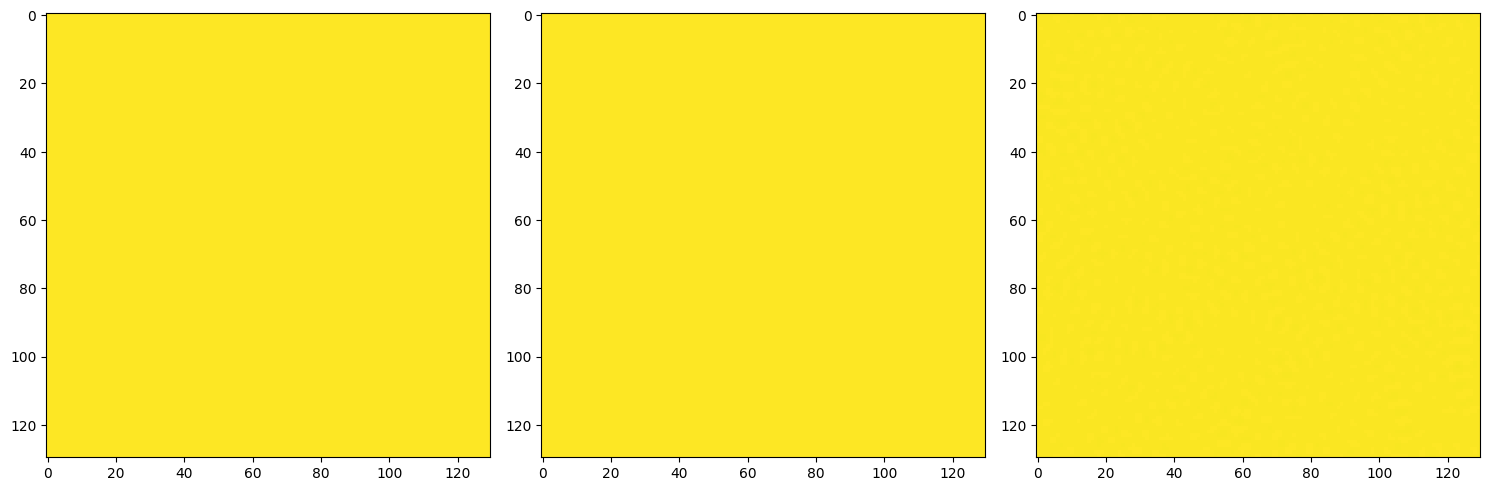

1
328.13947
286.00537
316.66412


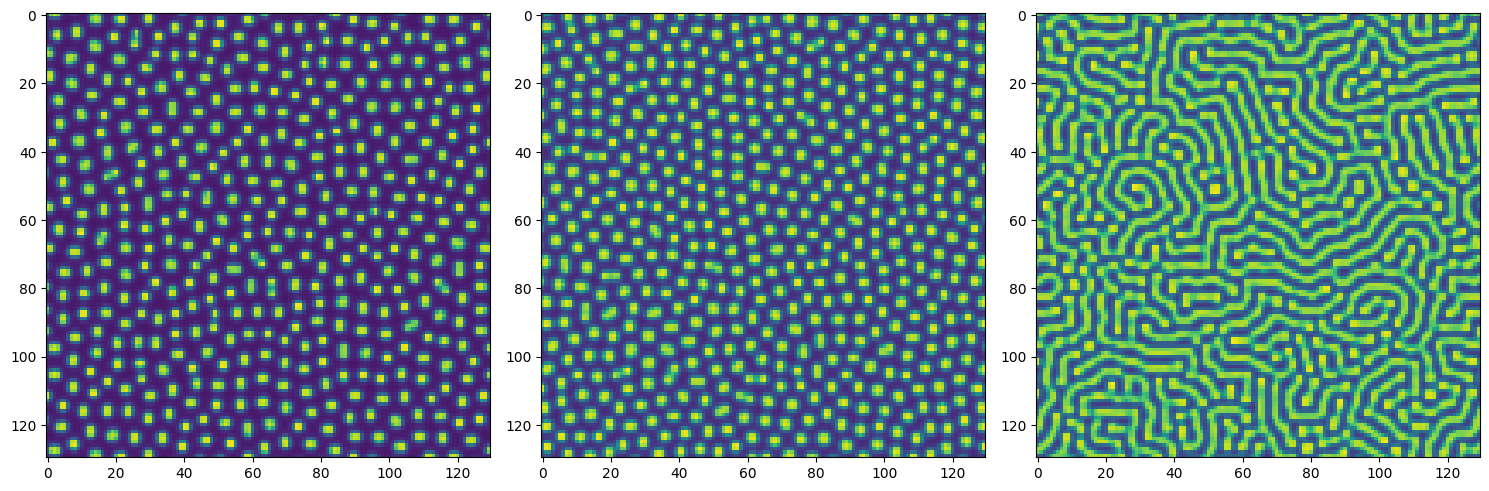

2
351.14117
781.6043
686.2048


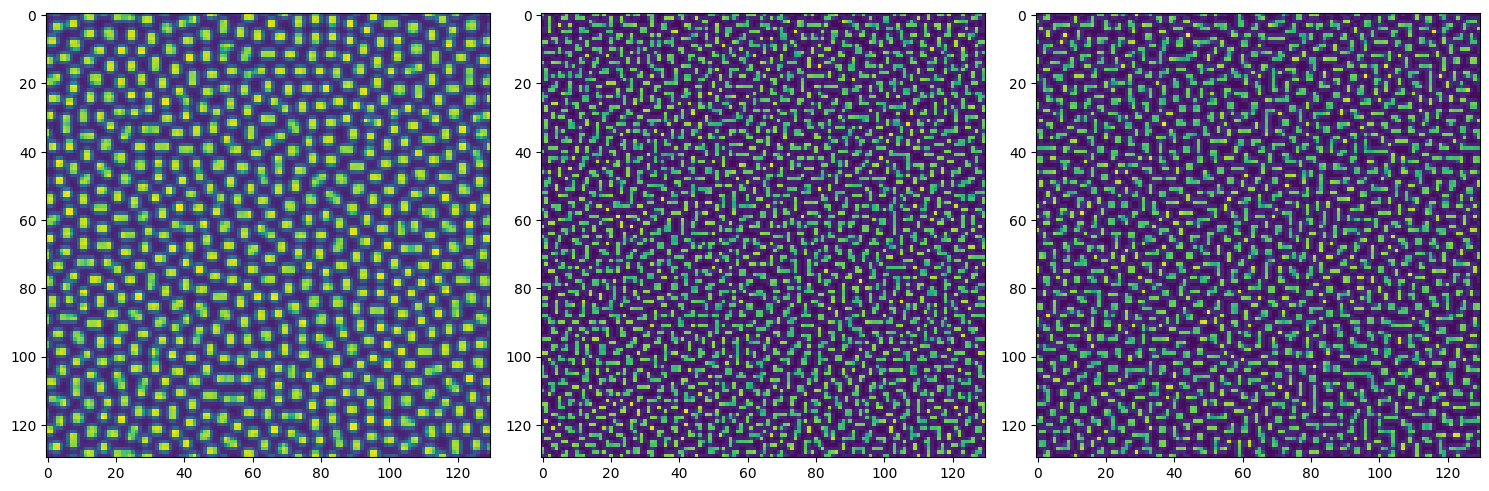

In [37]:
# for each value of pattern_class, plot the final frame of three trajectories
for pc in [0, 1, 2]:
    df_pc = filter_df(df, pca_label=pc)
    if len(df_pc) < 3:
        continue
    print(pc)
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    for i, idx in enumerate(df_pc["idx"].sample(3).values):
        traj = ds.get_data(idx)
        ff = traj[-1, :, 0::2]
        # plot(ff, ax=ax[i], title=f"Pattern Class {pc}, Trajectory {idx}")
        ax[i].imshow(ff, cmap="viridis", vmin=0)
        print(df.iloc[idx].mean_deviation)
    plt.tight_layout()
    plt.show()

In [30]:
grouped_var = df.groupby(['A', 'ratio_b_a'])['mean_deviation'].var().reset_index(name='var_mean_deviation')
mean_pca = df.groupby(['A', 'ratio_b_a'])['pattern_class'].mean().reset_index(name='mean_pca_label')
df_grp = grouped_var.merge(mean_pca, on=['A', 'ratio_b_a'], how='left')

In [31]:
df_grp.loc[df_grp.var_mean_deviation <= 100, "merge_label"] = 0
df_grp.loc[(df_grp.var_mean_deviation > 100) & (df_grp.mean_pca_label.between(0.5,1.5,inclusive='both')), "merge_label"] = 1
df_grp.loc[(df_grp.var_mean_deviation > 100) & (df_grp.mean_pca_label == 2), "merge_label"] = 2

df_grp.merge_label = df_grp.merge_label.astype("str")

In [34]:
fig = px.scatter_3d(
    df_grp,
    x="A",
    y="ratio_b_a",
    z="var_mean_deviation", 
    color="merge_label",
    color_continuous_scale=px.colors.sequential.Bluered,
    labels={
            "ratio_b_a": "B/A",
            "var_mean_deviation": "Variance wrt. Dv",
        },
    color_discrete_sequence=set1_colors,

)

fig.update_layout(
    scene_camera=dict(
        eye=dict(x=-1.8, y=-0.8, z=0.8),
        center=dict(x=0, y=0, z=-0.25)
    )
)
fig.update_traces(marker_size=5)
fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=0)
)

fig.show()

In [35]:
fig.update_traces(marker_size=1.5, marker=dict(line=dict(width=2, color='black')))
fig.write_image("grid_scatter_var-mean-dev.png", width=1.5*500, height=1.5*300, scale=3)

In [37]:
fig = go.Figure()
labels = ['Homogeneous', 'Transitory region', 'Pattern formation']
colors = ['#E41A1C', '#377EB8', '#4DAF4A']

for label, color in zip(labels, colors):
    fig.add_trace(go.Scatter(
        x=[None], y=[None],  # No data shown
        mode='markers',
        marker=dict(size=15, color=color, line=dict(width=2, color='black')),
        name=label
    ))

fig.update_layout(
    showlegend=True,
    legend=dict(
        font=dict(size=20),
        title='Classification',
        orientation='v',  # 'h' for horizontal
        x=0.5, xanchor='center', y=0.5, yanchor='middle'
    ),
    xaxis=dict(visible=False),
    yaxis=dict(visible=False),
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=0, r=0, t=0, b=0)
)
fig.write_image("var_legend.png", width=400, height=300, scale=2)

In [34]:
df_steady = df_grp[df_grp.var_mean_deviation <= 100]
df_steady['merge_label'] = 0
df_trans = df_grp[(df_grp.var_mean_deviation > 100) & (df_grp.mean_pca_label.between(0.5,1.5,inclusive='both'))]
df_trans['merge_label'] = 1
df_high = df_grp[(df_grp.var_mean_deviation > 100) & (df_grp.mean_pca_label == 2)]
df_high['merge_label'] = 2

/scratch/tmp.33925203.vogtva/ipykernel_2791445/3114594303.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/scratch/tmp.33925203.vogtva/ipykernel_2791445/3114594303.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/scratch/tmp.33925203.vogtva/ipykernel_2791445/3114594303.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/st

In [35]:
df_centers = pd.concat([df_steady.sample(5),
df_trans.sample(30),
df_high.sample(15)])

In [36]:
df_res = pd.DataFrame(columns=df.columns)
for i, row in df_centers.iterrows():
    # print(row['merge_label'])
    row = row.drop(['var_mean_deviation', 'mean_pca_label', 'merge_label'])
    df_filt = filter_df(df, **row)
    if len(df_filt) > 0:
        df_res = pd.concat([df_res, df_filt.sample()])
    else:
        print(row)
    # plot(d, 0, np.max(d))
    # plt.show()

/scratch/tmp.33925203.vogtva/ipykernel_2791445/233233760.py:7: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



In [37]:
model = "bruss"
ds_id = "final"
ds, output_dir = get_dataset(model, ds_id, "SCRATCHDIR")
df_final = ds.df
df_final["ratio_b_a"] = df_final["B"] / df_final["A"]
df_final["ratio_d"] = df_final["Dv"] / df_final["Du"]

In [38]:
# First scatter (converted to a trace)
fig1 = px.scatter_3d(
    df_grp,
    x="A",
    y="ratio_b_a",
    z="var_mean_deviation", 
    color="mean_pca_label",
    color_continuous_scale=px.colors.sequential.Bluered,
)
fig1.update_traces(marker_size=2)

# Extract the trace(s) from the first figure
fig = go.Figure(data=fig1.data)

# Second scatter (manual trace)
fig.add_trace(
    go.Scatter3d(
        x=df_final["A"],
        y=df_final["ratio_b_a"],
        z=[0] * len(df_final),
        mode='markers',
        marker=dict(size=1, color='black'),
        name='df_final points'
    )
)

fig.show()


In [39]:
from sklearn.neighbors import NearestNeighbors

In [40]:
X_grp = df_grp[["A", "ratio_b_a"]].to_numpy()
X_final = df_final[["A", "ratio_b_a"]].to_numpy()

# Fit nearest neighbor model
nn = NearestNeighbors(n_neighbors=1, algorithm='auto')
nn.fit(X_grp)

# Find closest points
distances, indices = nn.kneighbors(X_final)

# Extract corresponding labels
closest_labels = df_grp.iloc[indices.flatten()]["mean_pca_label"].to_numpy()

# Optionally, assign to df_final
df_final["closest_mean_pca_label"] = closest_labels

In [46]:
fig = px.scatter_3d(
    df_final,
    x="A",
    y="B",
    z="ratio_d",
    color="closest_mean_pca_label",
    opacity=0.7,
)
fig.update_traces(marker_size=2)
fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=0)
)

fig.show()

In [43]:
df_final.value_counts('closest_mean_pca_label') / len(df_final)

closest_mean_pca_label
2.0    0.3404
1.5    0.2494
1.0    0.1658
0.0    0.1412
0.5    0.1032
Name: count, dtype: float64